前5行数据：
            Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0 2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1 2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2 2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3 2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4 2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   

  HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday  \
0        On           Off         2.774699     Monday      No   
1        On            On        21.831384   Saturday      No   
2       Off           Off         6.764672     Sunday      No   
3       Off            On         8.623447  Wednesday      No   
4        On           Off         3.071969     Friday      No   

   EnergyConsumption  
0          75.364373  
1          83.401855  
2          78.270888  
3          56.519850  
4          70.811732  

列名：
Index(['

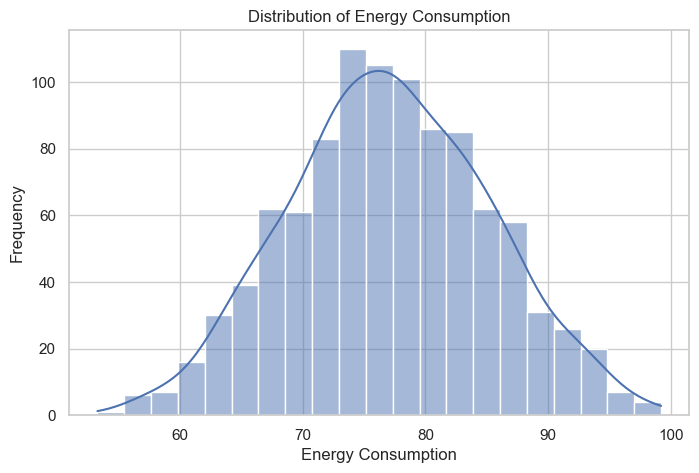

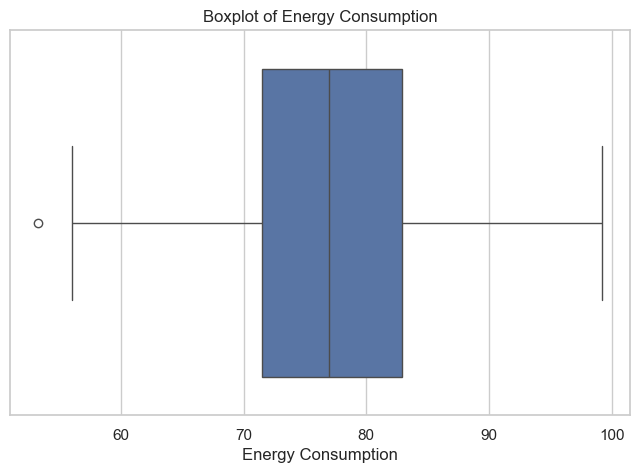

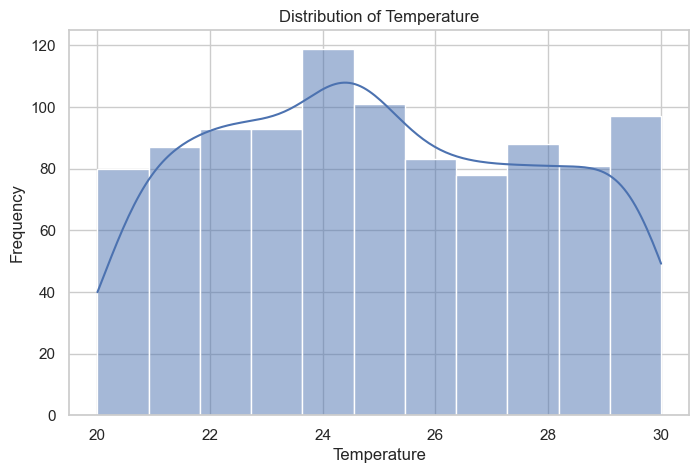

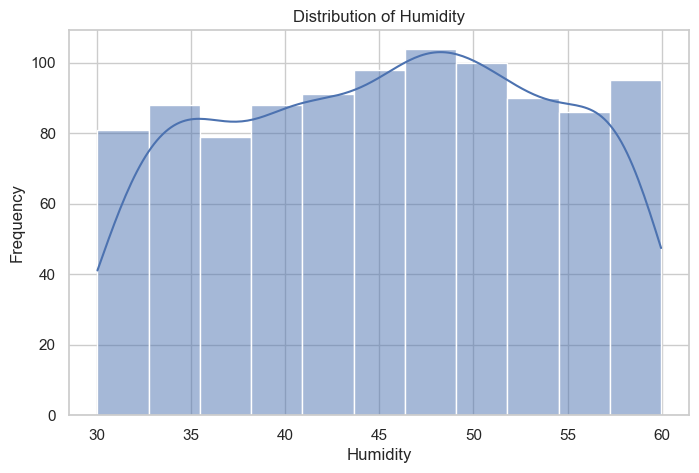

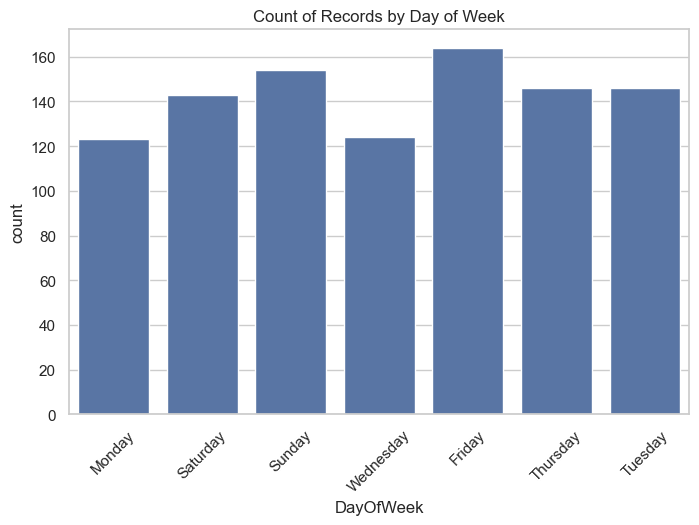

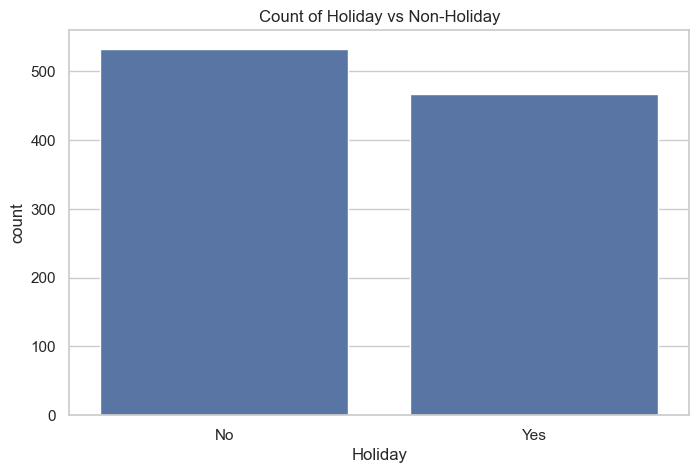

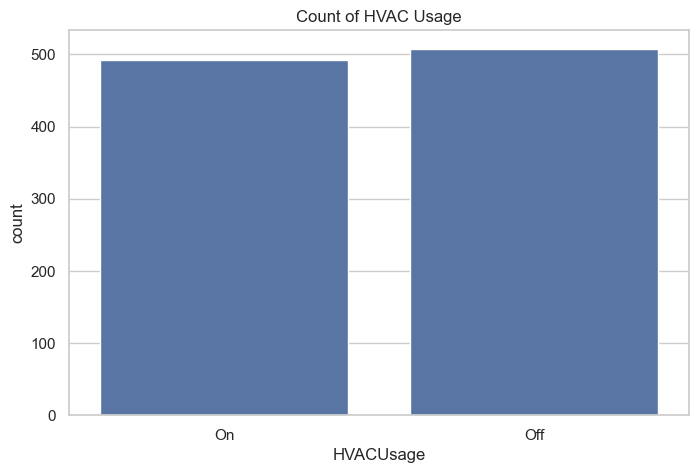

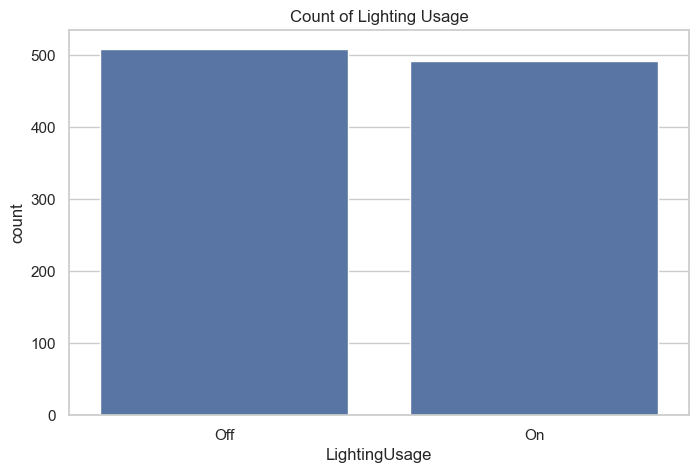

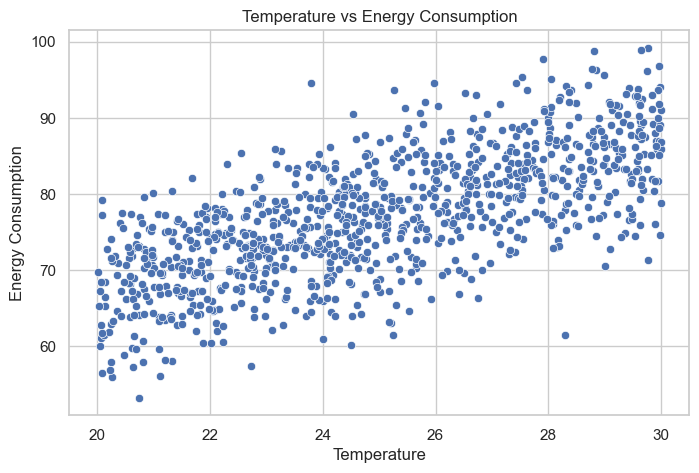

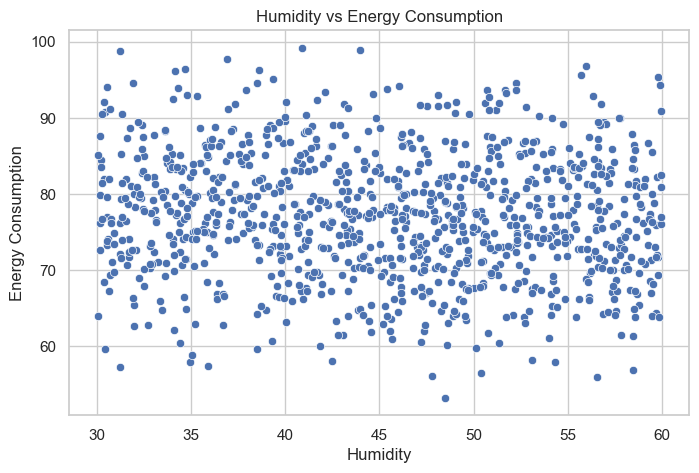

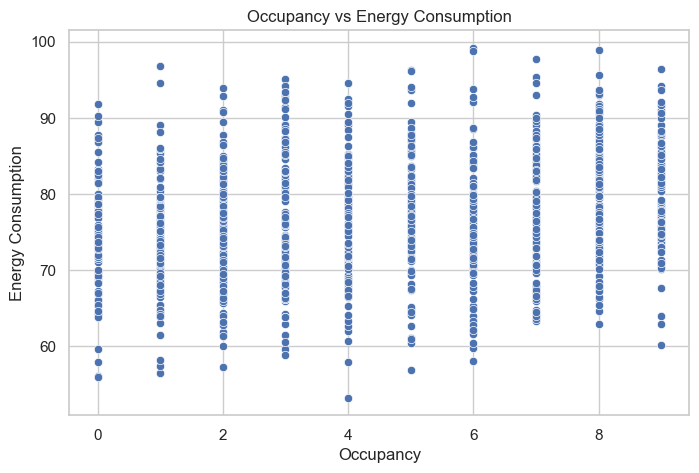

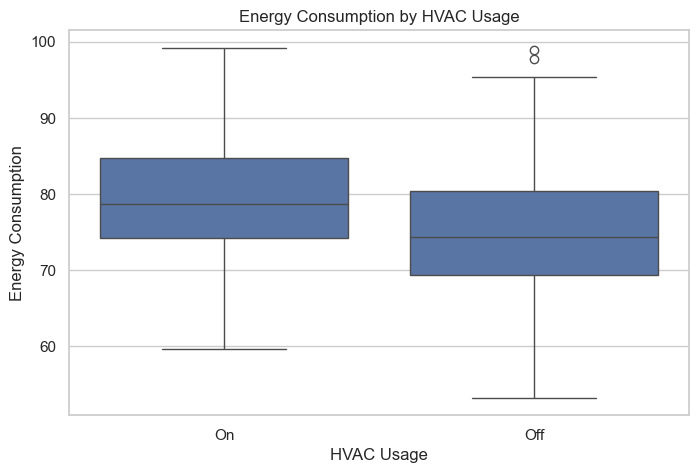

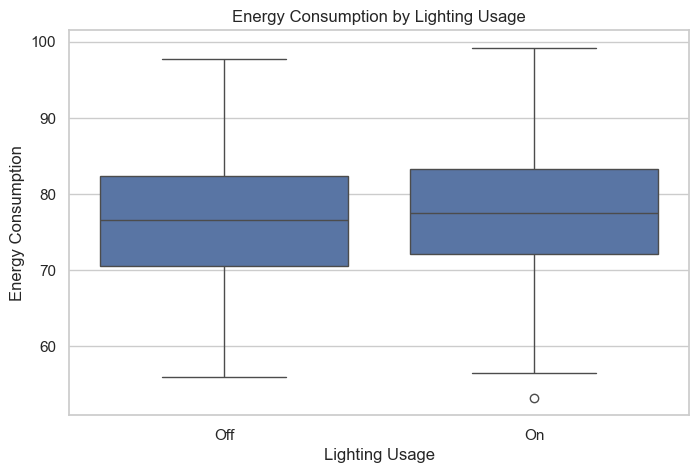

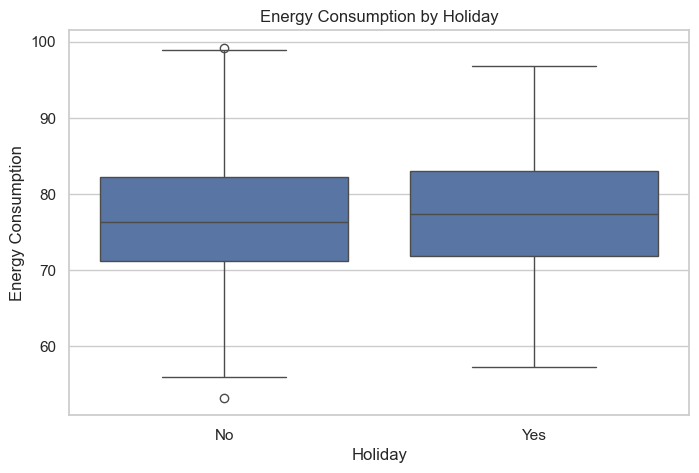

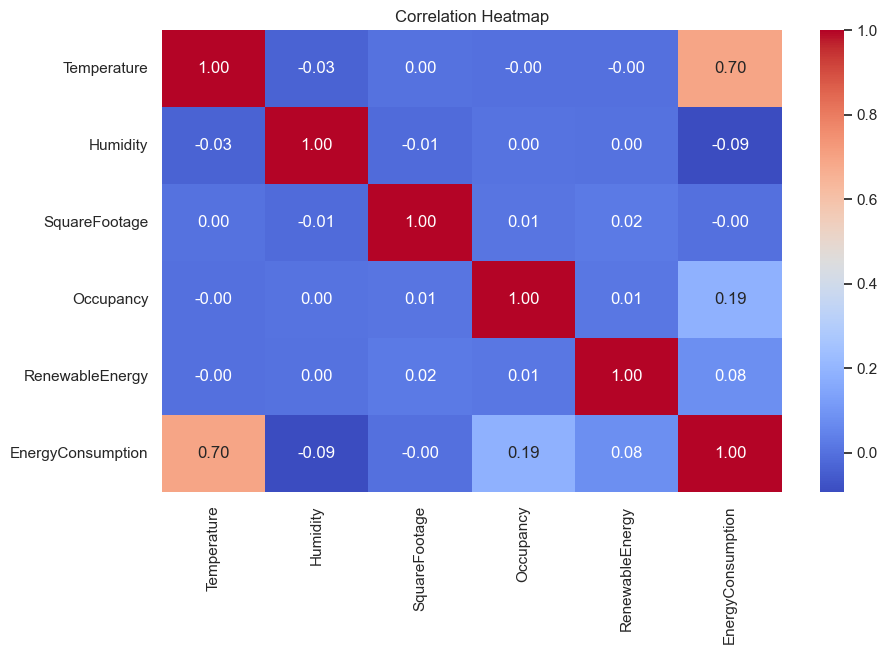

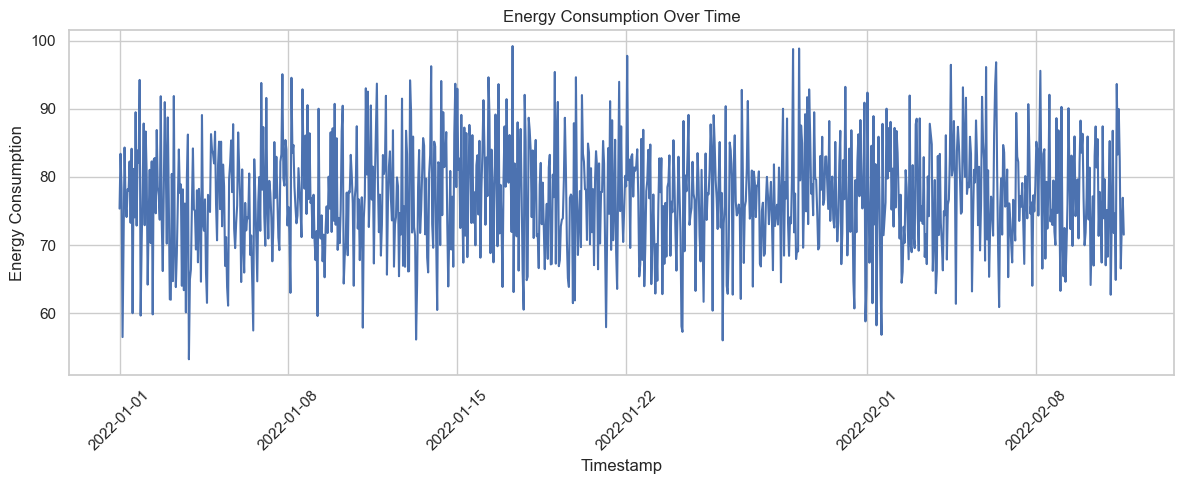

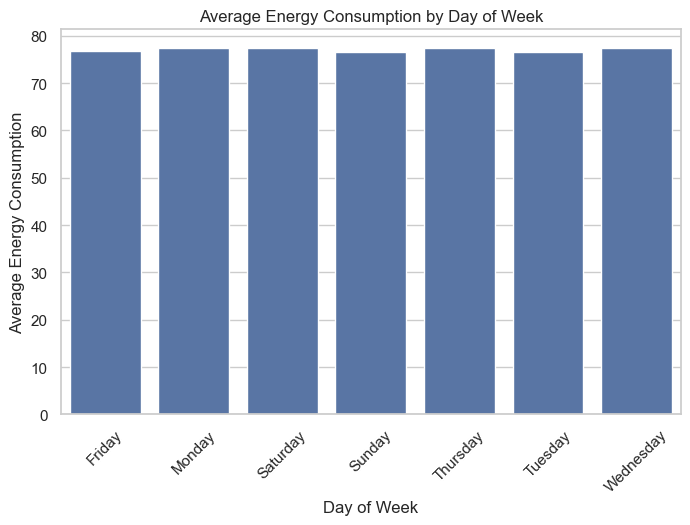

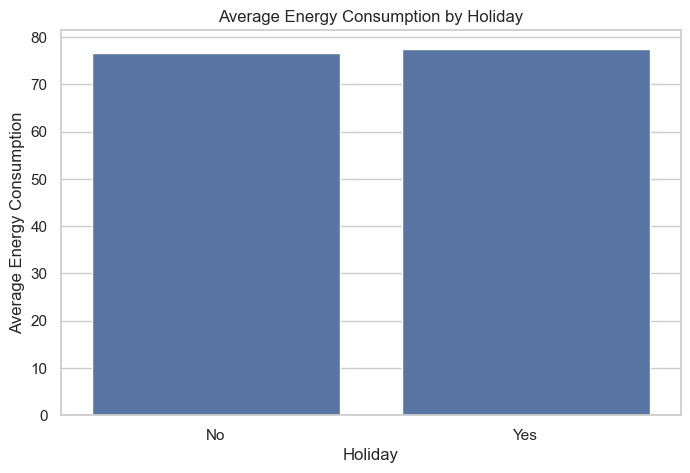

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
sns.set(style="whitegrid")

# 读取数据
df = pd.read_csv("Energy.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 查看数据
print("前5行数据：")
print(df.head())

print("\n列名：")
print(df.columns)

print("\n数据基本信息：")
print(df.info())

print("\n描述统计：")
print(df.describe())

print("\n缺失值数量：")
print(df.isnull().sum())

# 单变量图
sns.histplot(df["EnergyConsumption"], kde=True)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")
plt.show()

sns.boxplot(x=df["EnergyConsumption"])
plt.title("Boxplot of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.show()

sns.histplot(df["Temperature"], kde=True)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

sns.histplot(df["Humidity"], kde=True)
plt.title("Distribution of Humidity")
plt.xlabel("Humidity")
plt.ylabel("Frequency")
plt.show()

# 类别图
sns.countplot(x="DayOfWeek", data=df)
plt.title("Count of Records by Day of Week")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x="Holiday", data=df)
plt.title("Count of Holiday vs Non-Holiday")
plt.show()

sns.countplot(x="HVACUsage", data=df)
plt.title("Count of HVAC Usage")
plt.show()

sns.countplot(x="LightingUsage", data=df)
plt.title("Count of Lighting Usage")
plt.show()

# 双变量图
sns.scatterplot(x="Temperature", y="EnergyConsumption", data=df)
plt.title("Temperature vs Energy Consumption")
plt.xlabel("Temperature")
plt.ylabel("Energy Consumption")
plt.show()

sns.scatterplot(x="Humidity", y="EnergyConsumption", data=df)
plt.title("Humidity vs Energy Consumption")
plt.xlabel("Humidity")
plt.ylabel("Energy Consumption")
plt.show()

sns.scatterplot(x="Occupancy", y="EnergyConsumption", data=df)
plt.title("Occupancy vs Energy Consumption")
plt.xlabel("Occupancy")
plt.ylabel("Energy Consumption")
plt.show()

sns.boxplot(x="HVACUsage", y="EnergyConsumption", data=df)
plt.title("Energy Consumption by HVAC Usage")
plt.xlabel("HVAC Usage")
plt.ylabel("Energy Consumption")
plt.show()

sns.boxplot(x="LightingUsage", y="EnergyConsumption", data=df)
plt.title("Energy Consumption by Lighting Usage")
plt.xlabel("Lighting Usage")
plt.ylabel("Energy Consumption")
plt.show()

sns.boxplot(x="Holiday", y="EnergyConsumption", data=df)
plt.title("Energy Consumption by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Energy Consumption")
plt.show()

# 热力图
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 时间序列图
plt.figure(figsize=(12, 5))
plt.plot(df["Timestamp"], df["EnergyConsumption"])
plt.title("Energy Consumption Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 分组分析
day_energy = df.groupby("DayOfWeek")["EnergyConsumption"].mean().reset_index()
sns.barplot(x="DayOfWeek", y="EnergyConsumption", data=day_energy)
plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy Consumption")
plt.xticks(rotation=45)
plt.show()

holiday_energy = df.groupby("Holiday")["EnergyConsumption"].mean().reset_index()
sns.barplot(x="Holiday", y="EnergyConsumption", data=holiday_energy)
plt.title("Average Energy Consumption by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Energy Consumption")
plt.show()